In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV, ElasticNetCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import joblib

RANDOM_SEED = 9876

PROJECT_ROOT = Path('.')
DATA_DIR = PROJECT_ROOT / 'data'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'

for d in [PROCESSED_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)


In [2]:
central_path = DATA_DIR / 'Central2024P.csv'
test_path = DATA_DIR / 'Central2024testP.csv'


central = pd.read_csv(central_path)
central_test_external = pd.read_csv(test_path)

central.head()

,Price,Area,Age,Tenure,Purchaser,Region
0,1412345.0,678.13,7,Leasehold,HDB,Bishan
1,960000.0,484.38,7,Leasehold,Private,Bishan
2,2180000.0,1280.92,8,Leasehold,HDB,Bishan
3,2450000.0,1248.62,12,Leasehold,Private,Bishan
4,2300000.0,1367.03,8,Leasehold,Private,Bishan


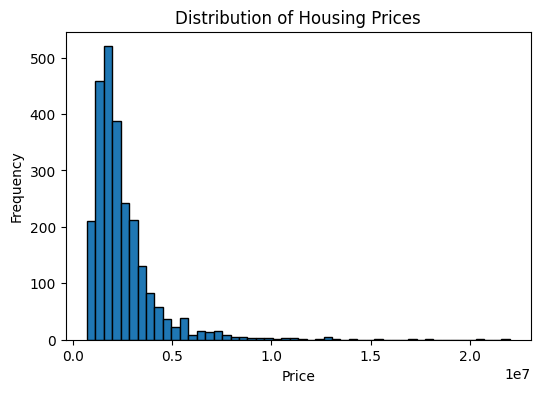

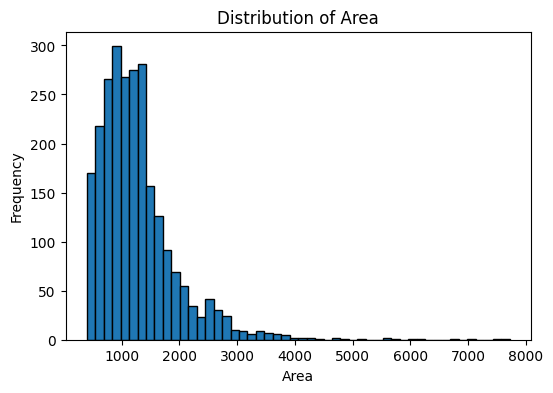

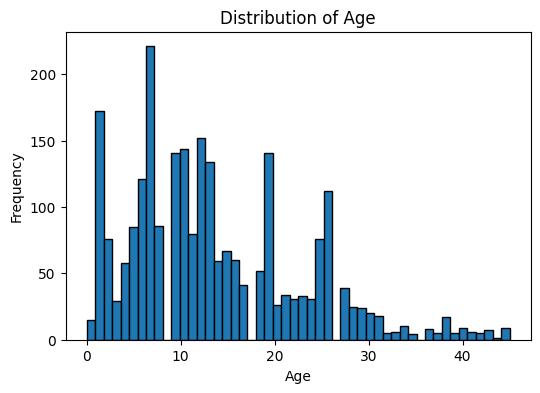

In [3]:
plt.figure(figsize=(6, 4))
plt.hist(central['Price'], bins=50, edgecolor='black')
plt.title('Distribution of Housing Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig(FIGURES_DIR / 'price_hist.png', dpi=200)
plt.show()


plt.figure(figsize=(6,4))
plt.hist(central['Area'], bins=50, edgecolor='black')
plt.title('Distribution of Area')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.savefig(FIGURES_DIR / 'area_hist.png', dpi=200)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(central['Age'], bins=50, edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig(FIGURES_DIR / 'age_hist.png', dpi=200)
plt.show()

## Train/Validation/Test Splits

- 10% holdout for final evaluation 
- 80/20 train/validation split for model comparison within training set


In [4]:
central['Price'] = np.log1p(central['Price'])
central['Area'] = np.log1p(central['Area'])



central_train, central_test = train_test_split(
    central_processed,
    test_size=0.1,
    random_state=RANDOM_SEED
)

train_df, val_df = train_test_split(
    central_train,
    test_size=0.2,
    random_state=RANDOM_SEED
)

central_train.shape, val_df.shape, central_test.shape

((2250, 6), (450, 6), (250, 6))

In [5]:
X_train = train_df.drop(columns=['Price'])  
y_train = train_df['Price']
X_val = val_df.drop(columns=['Price'])
y_val = val_df['Price']



## Polynomial degree selection (Area, Age) via 10-fold CV



In [6]:
def poly_cv_mse(df, feature, target='Price', max_degree=10, k=10, random_state=RANDOM_SEED):
    kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
    mse_per_degree = []
    X = df[[feature]].values
    y = df[target].values

    for degree in range(1, max_degree + 1):
        fold_mse = []
        for train_idx, test_idx in kf.split(X):
            X_train = X[train_idx]
            X_test = X[test_idx]
            y_train = y[train_idx]
            y_test = y[test_idx]

            # Create polynomial features manually
            X_train_poly = np.column_stack([X_train ** d for d in range(1, degree + 1)])
            X_test_poly = np.column_stack([X_test ** d for d in range(1, degree + 1)])

            model = LinearRegression()
            model.fit(X_train_poly, y_train)
            preds = model.predict(X_test_poly)
            fold_mse.append(mean_squared_error(y_test, preds))

        mse_per_degree.append(np.mean(fold_mse))

    return mse_per_degree

area_cv_mse = poly_cv_mse(central_train, 'Area')
age_cv_mse = poly_cv_mse(central_train, 'Age')

best_degree_area = int(np.argmin(area_cv_mse) + 1)
best_degree_age = int(np.argmin(age_cv_mse) + 1)

best_degree_area, best_degree_age

(7, 9)

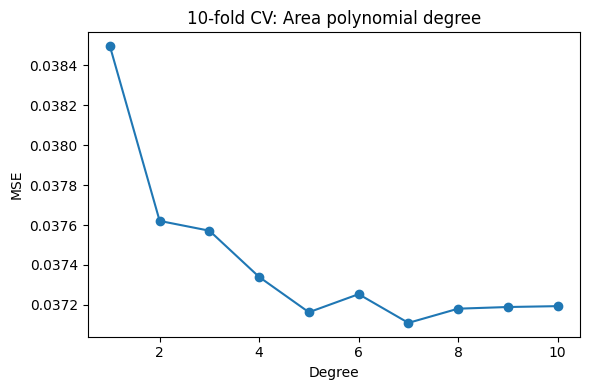

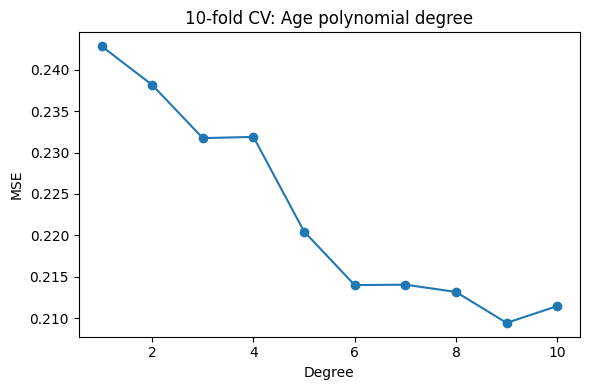

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), area_cv_mse, marker='o')
plt.title('10-fold CV: Area polynomial degree')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_poly_area.png', dpi=200)
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), age_cv_mse, marker='o')
plt.title('10-fold CV: Age polynomial degree')
plt.xlabel('Degree')
plt.ylabel('MSE')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cv_poly_age.png', dpi=200)
plt.show()

## Feature Engineering Pipeline

Includes:
- Polynomial terms for Area/Age (CV-selected)
- Interactions: Area×Age



In [17]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, degree_area=1, degree_age=1):
        self.degree_area = degree_area
        self.degree_age = degree_age

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
    
        # Polynomial terms
        for d in range(2, self.degree_area + 1):
            df[f'Area_^_{d}'] = df['Area'] ** d
        for d in range(2, self.degree_age + 1):
            df[f'Age_^_{d}'] = df['Age'] ** d

        # Interactions
        df['Area_x_Age'] = df['Area'] * df['Age']

        return df   
feature_engineer = FeatureEngineer(degree_area=best_degree_area, degree_age= best_degree_age)
sample_fe = feature_engineer.fit_transform(X_train)
numeric_features = sample_fe.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [col for col in X_train.columns if col not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
                    ]), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)


## Model Training (Lasso, Ridge, ElasticNet, XGBoost)

In [18]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def evaluate_model(name, model, X, y_log):
    preds_log = model.predict(X)
    preds = np.expm1(preds_log)
    y_true = np.expm1(y_log)
    return {
        'Model': name,
        'RMSE': rmse(y_true, preds),
        'MAE': mean_absolute_error(y_true, preds),
        'R2': r2_score(y_true, preds),
        'MAPE': mape(y_true, preds)
    }
    





lasso = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', LassoCV(cv=5, random_state=RANDOM_SEED))
])

ridge = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', RidgeCV(alphas=np.logspace(-3, 3, 50)))
])

elastic = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, random_state=RANDOM_SEED))
])

xgb = Pipeline([
    ('feature_engineer', feature_engineer),
    ('preprocess', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=RANDOM_SEED,
        n_estimators=500
    ))
])

models = {
    'LassoCV': lasso,
    'RidgeCV': ridge,
    'ElasticNetCV': elastic
}


In [ ]:

for name, model in models.items():
    model.fit(X_train, y_train)


In [20]:

# XGBoost with randomized search
param_distributions = {
    'model__max_depth': [3, 4, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__min_child_weight': [1, 5, 10]
}

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=param_distributions,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

## Validation performance comparison (primary metric: RMSE)

In [21]:
results = []
for name, model in models.items():
    results.append(evaluate_model(name, model, X_val, y_val))

results.append(evaluate_model('XGBoost', best_xgb, X_val, y_val))

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

,Model,RMSE,MAE,R2,MAPE
3,XGBoost,462296.567883,215742.809028,0.928326,6.897131
1,RidgeCV,581202.946396,289561.112148,0.886714,9.533719
0,LassoCV,590997.714436,291237.122161,0.882864,9.510181
2,ElasticNetCV,591056.287204,291199.403020,0.882841,9.509221


## Fit best model on full training set + evaluate on holdout

In [22]:
best_model_name = results_df.iloc[0]['Model']
best_model = {
    'LassoCV': models['LassoCV'],
    'RidgeCV': models['RidgeCV'],
    'ElasticNetCV': models['ElasticNetCV'],
    'XGBoost': best_xgb
}[best_model_name]

X_holdout = central_test.drop(columns=['Price'])
y_holdout = central_test['Price']


full_train = central_train.drop(columns=['Price'])

best_model.fit(full_train, central_train['Price'])
holdout_metrics = evaluate_model(best_model_name, best_model, X_holdout, y_holdout)
holdout_metrics

{'Model': 'XGBoost',
 'RMSE': 355432.1534803739,
 'MAE': 203495.18750000006,
 'R2': 0.9471632432697272,
 'MAPE': 7.291290229173092}

## External data (Central2024testP.csv)

In [23]:
X_external = central_test_external.drop(columns=['Price'])
X_external['Area'] = np.log1p(X_external['Area'])
y_external = np.log1p(central_test_external['Price'])
external_metrics = evaluate_model(best_model_name, best_model, X_external, y_external)
external_metrics 

{'Model': 'XGBoost',
 'RMSE': 997666.545450142,
 'MAE': 302097.8857493857,
 'R2': 0.8328608121416405,
 'MAPE': 8.23528257410254}

## Diagnostics and plots

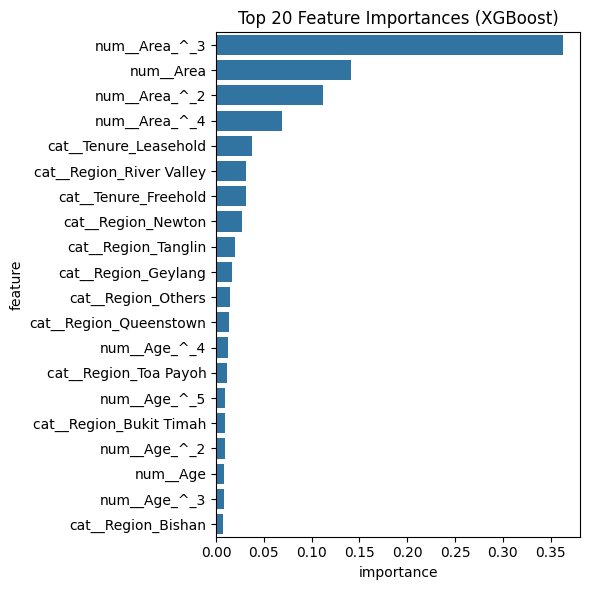

In [24]:
# XGBoost feature importance
if best_model_name == 'XGBoost':
    booster = best_model.named_steps['model']
    importance = booster.feature_importances_
    feature_names = (
        best_model.named_steps['preprocess']
        .get_feature_names_out()
    )
    fi = pd.DataFrame({'feature': feature_names, 'importance': importance})
    fi = fi.sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(6, 6))
    sns.barplot(data=fi, x='importance', y='feature')
    plt.title('Top 20 Feature Importances (XGBoost)')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'xgb_feature_importance.png', dpi=200)
    plt.show()

## Save artifacts

In [25]:
central_train.to_csv(PROCESSED_DIR / 'central_train.csv', index=False)
central_test.to_csv(PROCESSED_DIR / 'central_test.csv', index=False)

joblib.dump(best_model, MODELS_DIR / f'best_model_{best_model_name}.joblib')

results_df.to_csv(PROCESSED_DIR / 'model_comparison.csv', index=False)
pd.DataFrame([holdout_metrics]).to_csv(PROCESSED_DIR / 'holdout_metrics.csv', index=False)
pd.DataFrame([external_metrics]).to_csv(PROCESSED_DIR / 'external_metrics.csv', index=False)

results_df

,Model,RMSE,MAE,R2,MAPE
3,XGBoost,462296.567883,215742.809028,0.928326,6.897131
1,RidgeCV,581202.946396,289561.112148,0.886714,9.533719
0,LassoCV,590997.714436,291237.122161,0.882864,9.510181
2,ElasticNetCV,591056.287204,291199.403020,0.882841,9.509221
